In [20]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import scipy.io as sio
from dataclasses import dataclass
from typing import List, Tuple
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from natsort import natsorted
import numpy as np
import matplotlib.animation as animation
import xarray as xr
import h5py
import imageio
import matplotlib
import gc
import sys
import io
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from scipy.optimize import curve_fit
import scipy.integrate


# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM
# plt.rcParams.update({'font.size': 6.7})  

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial',size=18)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
exit_intensity_data = rf"./data/20251212_intensities_exit.h5"
data_intensities_exit =AM.read_hdf5_as_dict(exit_intensity_data)
data_intensities_exit.keys()
# data_field_intensities key containes the flux
            

dict_keys(['chi', 'data_field_intensities', 'data_field_intensities_2', 'f', 'sample', 'size', 'x'])

In [22]:
data_intensities_exit["data_field_intensities"].shape # (num_chi, num_size, sample, num_freq)

(13, 16, 5, 957, 150)

In [23]:
data_intensities_exit["size"]

array([ 0.5,  1. ,  2. ,  3. ,  4. ,  5. ,  6. ,  7. ,  8. ,  9. , 10. ,
       11. , 12. , 13. , 14. , 15. ])

In [24]:
colors = [
          (1, 1, 1),  # White
          (0, 0, 1),  # Blue
          (1, 1, 0),  # Yellow
          (0, 1, 0),  # Green
          (1, 0, 0), #Red
          (0, 0, 0), # Black
          ]  

# Create a custom colormap
n_bins = 500  # Number of bins for smooth transition
cmap = mcolors.LinearSegmentedColormap.from_list("custom_colormap", colors, N=n_bins)

In [25]:
window = 5
def calculate_IPR(intensity_array,x1):
    values = intensity_array
    integral_1 = scipy.integrate.simpson(values**2, x=x1, axis=0)
    integral_2 = scipy.integrate.simpson(values, x=x1,axis=0)**2

    return integral_1/integral_2

def moving_average(x, w=window):
    return np.convolve(x, np.ones(w), 'valid') / w

def calculate_sigma(intensity_array, x1):
    x1 = np.asarray(x1)
    values = intensity_array

    # Reshape x1 to broadcast over columns (axis=1)
    x1 = x1[:, np.newaxis]  

    norm = scipy.integrate.trapezoid(values, x=x1[:, 0], axis=0)
    mean = scipy.integrate.trapezoid(values * x1, x=x1[:, 0], axis=0) / norm
    mean_sq = scipy.integrate.trapezoid(values * x1**2, x=x1[:, 0], axis=0) / norm
    sigma = np.sqrt(mean_sq - mean**2)
    return sigma


average_xis_exit = np.zeros(shape=(11,16,150-window+1)) #chi, size, freq
data_exit = np.copy(data_intensities_exit["data_field_intensities_2"])
for i,chi in enumerate(data_exit):
    if i in [0,12]:
        continue
    for j,length in enumerate(chi): 
        intensities =[]
        for k,sample in enumerate(length):
            # mask = sample/np.max(sample)>1e-9
            sample_normalized = sample/np.max(sample,axis=0)
            # sample_normalized[~mask]=0
            intensities.append(sample_normalized)

        average_intensity = np.mean(intensities,axis=0)
        average_xis_exit[i-1,j]=moving_average(calculate_IPR(average_intensity,data_intensities_exit["x"]))

average_xis_exit[np.isnan(average_xis_exit)] = 0
average_xis_exit[np.isinf(average_xis_exit)] = 0

In [26]:
#grab the bandgap data
gap_data_path = rf"../20250623 MPB Bands/20251215_Process_Bands/data/20251215_eps_11p56_chi_0p3_0p37_bgw_list.h5"
gap_data = AM.read_hdf5_as_dict(gap_data_path)
gap_data.keys()

dict_keys(['0.3', '0.31', '0.32', '0.33', '0.34', '0.35', '0.36', '0.37', '0.38', '0.39', '0.4'])

In [27]:
#Calculate average gap edges 
band_edge_array = np.array([np.mean([gap_data[str(chi)][str(sample)]["gap_edges"]
                    for sample in gap_data[str(chi)].keys()],
                    axis=0) for chi in gap_data.keys()]).squeeze()

band_edge_array.shape

(11, 2)

In [28]:
# #gap data from Luis 
# luis_gap_data_path = rf"H:\phd stuff\tidy3d\Notebooks\2D SHU Project\20250623 MPB Bands\Luis Data\band_structure_stats\20251218_bandgaps_chi_0p30_0p40_tolerance_0.02.h5"
# gap_data_luis = AM.read_hdf5_as_dict(luis_gap_data_path)

low_nDOS_boundaries=np.array([[0.297,0.297,0.299,0.303,0.308,0.315,0.323,0.333,0.338,0.343,0.354, 0.375, 0.380,0.380,0.384, 0.387, 0.390,0.394,0.398,0.401,0.404,0.407 ],
                         [0.40 , 0.39 , 0.38, 0.37,0.36,0.35,0.34,0.33,0.32,0.31, 0.30, 0.30,0.31,0.32,0.33,0.34,0.35,0.36,0.37, 0.38 , 0.39, 0.40]])

# PBG_boundaries=np.array([[0.297, 0.297 ,0.299, 0.3221,0.356,0.3679,0.3650,0.3659,0.3632,  0.3643, 0.3675,0.3677,0.3767,0.3833,0.3869, 0.401, 0.404, 0.407 ],
#                          [0.40 , 0.39 , 0.38, 0.37,0.36,0.35,0.34,0.33,0.32,0.32,0.33,0.34,0.35,0.36,0.37, 0.38 , 0.39, 0.40]])

PBG_boundaries=np.array([[0.297, 0.297 ,0.299, 0.3221,0.356,0.3679,0.3767,0.3833,0.3869, 0.401, 0.404, 0.407 ],
                         [0.40 , 0.39 , 0.38, 0.37,0.36,0.35,0.35,0.36,0.37, 0.38 , 0.39, 0.40]])

half = low_nDOS_boundaries[0].size // 2

band_edge_array =(np.c_[low_nDOS_boundaries[0, :half], low_nDOS_boundaries[0, :half-1:-1]])[::-1]

band_edge_array.shape

(11, 2)

In [29]:
sizes = [6,7,8,9,10,11]

C:\Users\HernandF\AppData\Local\Temp\ipykernel_16724\2653690678.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi_be_idx = np.arange(start_idx, np.shape(chi_new_values))
C:\Users\HernandF\AppData\Local\Temp\ipykernel_16724\2653690678.py:70: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax_flattened[j].plot(PBG_boundaries[0],PBG_boundaries[1],'k--',linewidth=1,color='#b63923')
C:\Users\HernandF\AppData\Local\Temp\ipykernel_16724\2653690678.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi_be_idx = np.arange(start_

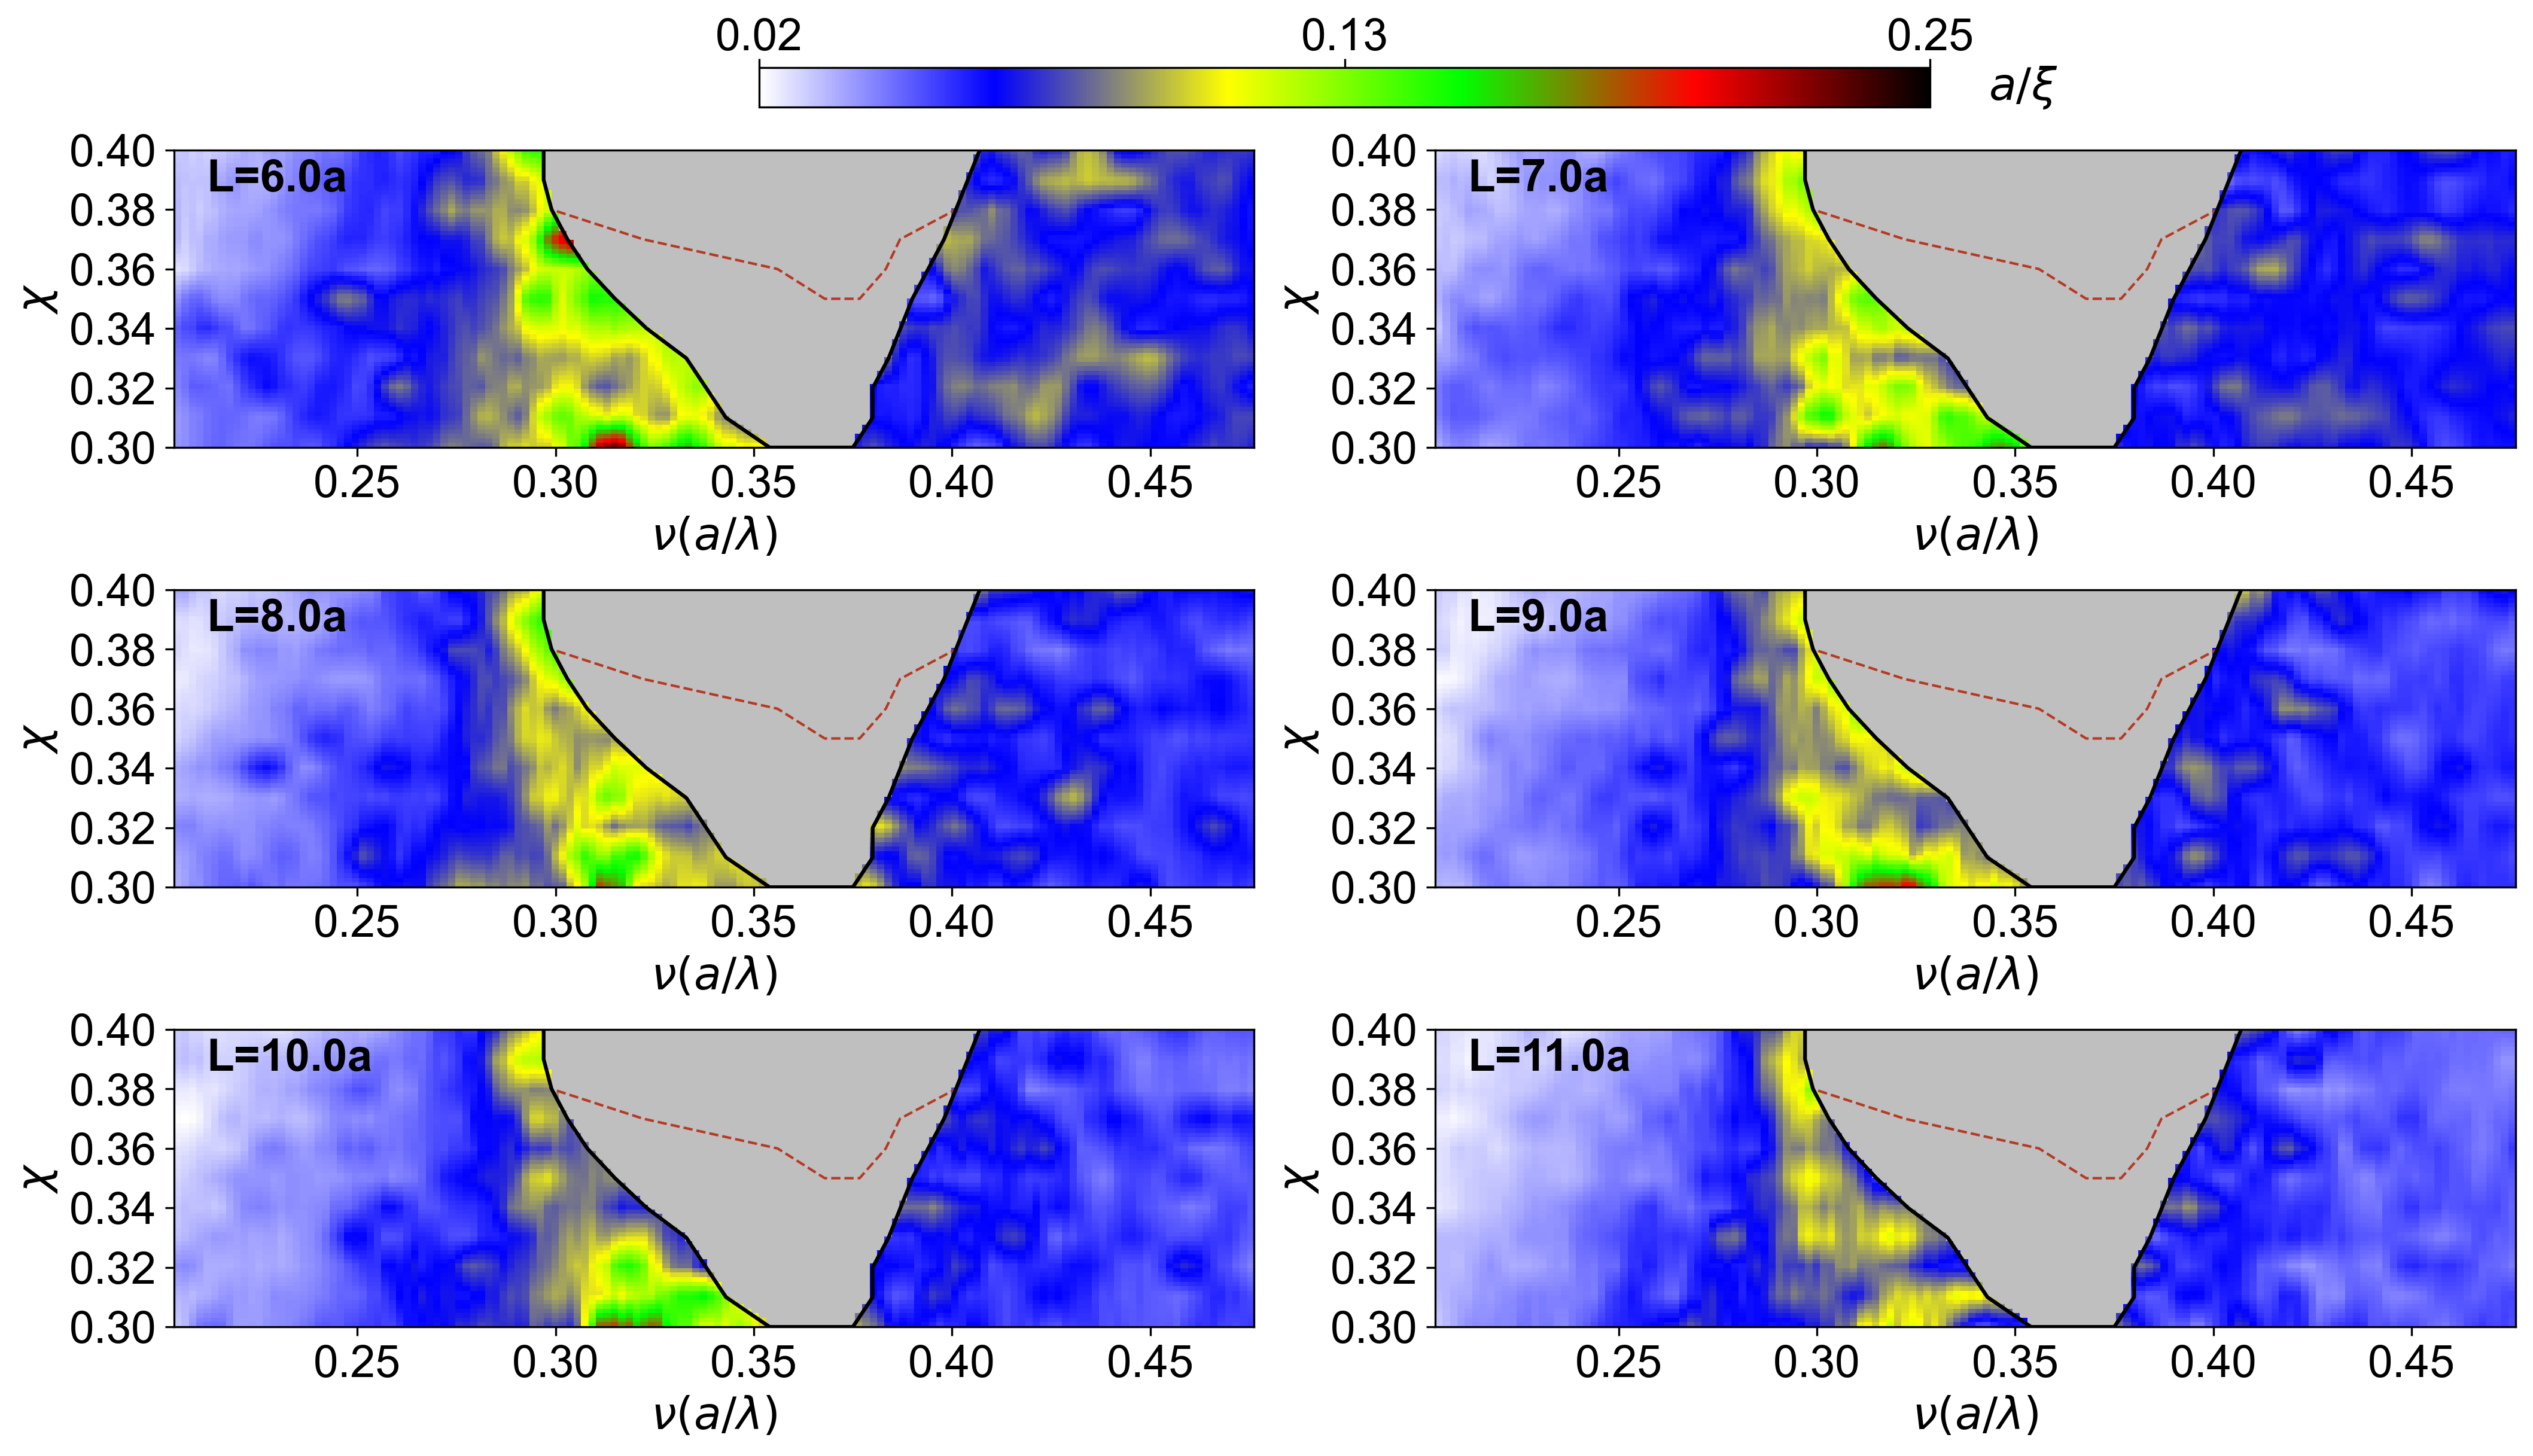

In [30]:
f = moving_average(data_intensities_exit["f"]/td.C_0)
j=0
fig, ax = plt.subplots(3,2,figsize=(14, 8), dpi=300, constrained_layout=True)
ax_flattened = ax.flatten()  # Flatten the 2D array of axes to 1D for easier indexing

cmap.set_bad(color='gray',alpha=0.5)  # Set masked bandgap region to gray

ims = []            # keep image handles so we can share one colorbar
global_vmin = np.inf
for h, length in enumerate(data_intensities_exit["size"]):
    if h not in sizes:
        continue
    value = np.copy(average_xis_exit[:, h, :])

    n_interp = 6  # upsample factor in y
    chi_old = np.arange(value.shape[0])
    chi_new = np.linspace(0, chi_old[-1], value.shape[0] * n_interp)

    f_interp = interp1d(chi_old, value, axis=0, kind='linear')
    value_yinterp = f_interp(chi_new)
    value = value_yinterp

    # Build mask for bandgap region
    chi_vals = np.array(data_intensities_exit["chi"])[1:-1]
    n_chi, n_f = value.shape
    mask = np.zeros_like(value, dtype=bool)
    chi_new_values = np.linspace(0.3, 0.4, value.shape[0])

    start_idx_arr = np.flatnonzero(np.isclose(chi_new_values, 0.30))
    if start_idx_arr.size:
        start_idx = start_idx_arr[0]
    else:
        start_idx = np.searchsorted(chi_new_values, 0.30)
    
    end_idx_arr = np.flatnonzero(np.isclose(chi_new_values, 0.4))
    if end_idx_arr.size:
        end_idx = end_idx_arr[0]
    else:
        end_idx = np.searchsorted(chi_new_values, 0.4)
    
    chi_be_idx = np.arange(start_idx, np.shape(chi_new_values))
    be = np.asarray(band_edge_array)   # shape (9, 2)

    f_grid = f[None, :]                        # (1, n_f)

    # Interpolate band-edge frequencies to the chi grid used by `value`
    # chi_vals was defined above and aligns with rows of `be`
    # chi_target are the chi values corresponding to chi_be_idx
    chi_target = chi_new_values[chi_be_idx]
    f_low_orig = be[:, 0]
    f_high_orig = be[:, 1]
    interp_low = interp1d(chi_vals, f_low_orig, axis=0, bounds_error=False, fill_value='extrapolate')
    interp_high = interp1d(chi_vals, f_high_orig, axis=0, bounds_error=False, fill_value='extrapolate')
    f_low_interp = interp_low(chi_target)[:, None]   # (len(chi_be_idx), 1)
    f_high_interp = interp_high(chi_target)[:, None] # (len(chi_be_idx), 1)

    mask[chi_be_idx,:] = (f_grid >= f_low_interp) & (f_grid <= f_high_interp)
    
    value = np.ma.array(value, mask=mask)

    global_vmin = min(global_vmin, np.min(value))

    im=ax_flattened[j].imshow(value, vmax=0.25,
                      extent =[np.min(f),np.max(f), 0.3,0.4], 
                         origin ='lower', cmap=cmap,
                         interpolation='nearest',   
                         aspect='auto') 
    ims.append(im)

    ax_flattened[j].plot(PBG_boundaries[0],PBG_boundaries[1],'k--',linewidth=1,color='#b63923')
    ax_flattened[j].plot(low_nDOS_boundaries[0],low_nDOS_boundaries[1],'k-')

    ax_flattened[j].set_xlabel(rf"$\nu(a/\lambda)$")
    ax_flattened[j].set_ylabel(rf"$\chi$")
    ax_flattened[j].tick_params(axis='both', which='major')
    yticks = np.arange(0.3, 0.4, 0.02)
    ax_flattened[j].set_yticks(yticks)
    ax_flattened[j].set_yticklabels([f"{t:.2f}" for t in yticks])
    ax_flattened[j].tick_params(axis='x', which='both', labelbottom=True)
    xticks = np.arange(0.25, 0.481, 0.05)
    ax_flattened[j].set_xticks(xticks)
    ax_flattened[j].set_xticklabels([f"{t:.2f}" for t in xticks])
    ax_flattened[j].tick_params(axis='x', which='both', labelbottom=True)
    subplot_label = rf"L={length}a"
    # Panel label placed inside the axes so it never collides with the colorbar
    ax_flattened[j].text(0.03, 0.97, subplot_label, transform=ax_flattened[j].transAxes,
                         fontsize=18, fontweight='bold', va='top', ha='left', color='k')
    j=j+1

# Put every subplot on the same color scale so a single colorbar is meaningful
for im in ims:
    im.set_clim(global_vmin, 0.25)

# One shared colorbar, centered above all subplots. constrained_layout reserves
# space for it, so it does not overlap the axes.
ticks = np.linspace(global_vmin, 0.25, 3)
cbar = fig.colorbar(ims[-1], ax=ax_flattened, orientation='horizontal',
                    location="top", shrink=0.5, aspect=30, pad=0.02, ticks=ticks)
cbar.ax.set_xticklabels([f"{t:.2f}" for t in ticks])
cbar.ax.tick_params(labelsize=18, pad=0)
cbar.ax.text(1.05, 0.5, rf"$a/ \xi$", va='center', ha='left', transform=cbar.ax.transAxes)

plt.savefig(rf'./figures/phase_diagram_L_sweep.pdf', bbox_inches='tight')
plt.show()